<a href="https://colab.research.google.com/github/marius-ne/CIE_ProjectB_Group13/blob/bozheng/%E2%80%9CProgram_B_ipynb%E2%80%9DCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIE 2025/26 RWTH, PROJECT B, GROUP 13
Junchao Yu, Marius Neuhalfen

ToDo:
- Find defective nodes by comparing perfect structure and imperfect structures for all scenarios
- Group defective nodes into regions (arc sections or track sections)
- Predict whether structure is perfect or imperfect
- Predict where the imperfection lies

There are 25.XXX for deformation and 24.XXX for stress

# Setup

In [1]:
import os
import sys
import itertools
import functools

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn

from pathlib import Path

In [2]:
pd.set_option('display.max_columns', 100)

## Data getting (if on Colab)

In [3]:
import google.colab
google.colab.drive.mount("/content/drive")

Mounted at /content/drive


Get ancillary data from Github

In [4]:
!git clone https://github.com/marius-ne/CIE_ProjectB_Group13.git

Cloning into 'CIE_ProjectB_Group13'...
remote: Enumerating objects: 196, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 196 (delta 5), reused 2 (delta 0), pack-reused 186 (from 1)
Receiving objects: 100% (196/196), 26.18 MiB | 18.40 MiB/s, done.
Resolving deltas: 100% (110/110), done.


## Load data

In [5]:
os.chdir("CIE_ProjectB_Group13")

In [6]:
os.getcwd()

'/content/CIE_ProjectB_Group13'

**IMPORTANT:** You need to add a shortcut of the "programB" folder on GoogleDrive to your own "MyDrive" for this to work

In [7]:
!ln -s /content/drive/MyDrive/programB data

In [8]:
target_folder = "data/Data2"
current_folder = os.getcwd()

if Path(current_folder).name != target_folder:
    os.chdir(Path(current_folder) / Path(target_folder))
print(os.getcwd())


/content/drive/.shortcut-targets-by-id/1s4mXuvtXeACi0SlotRW51MJ2xu6p5JfN/programB/Data2


Convert data

In [9]:
VARIABLES = {
      0: "TotalDeformation.csv",
      1: "DirectionalDeformation_X_axis.csv",
      2: "DirectionalDeformation_Y_axis.csv",
      3: "DirectionalDeformation_Z_axis.csv",
      4: "EquivalentStress.csv",
      5: "ShearStress_XY.csv",
      6: "ShearStress_XZ.csv",
      7: "ShearStress_YZ.csv",
  }
LOADS = {
    0: "Bigger_train",
    1: "Smaller_train",
}
SEASONS = {
    0: "Summer",
    1: "Winter",
}
HEALTHS = {
    0: "Perfect_structure",
    1: "ip_frst_Arc_defect_all_tracks_111",
    2: "ip_1and3track_3_arc_78910",
    3: "ip_first_track_3arc_78910",
    4: "Ip_1track_1_arc_345",
    5: "ip_3track_1_arc_678",
    6: "ip_2_arc_all_tracks_222",
}
TRAIN_CONFIGS = {
    0: "One_train_1st_track",
    1: "One_train_middle_track",
    2: "Two_trains_extreme_track_different_direction",
    3: "Two_trains_extreme_track_same_direction",
}
VARIABLE_NAMES = [var[:-4] for var in VARIABLES.values()]
NODE_NUMBERS = None

def combination_to_string(combination):
    train_config, load, season, health, variable = combination
    return f"{TRAIN_CONFIGS[train_config]}__{LOADS[load]}__{SEASONS[season]}__{HEALTHS[health]}__{VARIABLES[variable][:-4]}"

# Construct list of scenarios (combinations of train configs, loads, seasons, healths, variables)
#   Each scenario is a tuple of (train_config, load, season, health, variable), each encoded
#   as the corresponding key in the dictionaries above
combinations = itertools.product(
        TRAIN_CONFIGS.keys(),
        LOADS.keys(),
        SEASONS.keys(),
        HEALTHS.keys(),
        VARIABLES.keys()
    )
combinations = list(combinations)

# Group by variables, i.e. each group has all variables for one scenario
combinations_grouped_by_variable = [
    combinations[i:i + len(VARIABLES)] for i in range(0, len(combinations), len(VARIABLES))
]
# Group further by healths, i.e. each group has all healths for one scenario (train config, load, season)
combinations_grouped_by_health = [
    combinations_grouped_by_variable[i:i + len(HEALTHS)] for i in range(0, len(combinations_grouped_by_variable), len(HEALTHS))
]



In [10]:
perfect_combinations = [c for c in combinations if c[3] == 6 ]
ipfirstarcdefectalltracks_combinations = [c for c in combinations if c[3] == 5 ]
perfect_combinations, ipfirstarcdefectalltracks_combinations

([(0, 0, 0, 6, 0),
  (0, 0, 0, 6, 1),
  (0, 0, 0, 6, 2),
  (0, 0, 0, 6, 3),
  (0, 0, 0, 6, 4),
  (0, 0, 0, 6, 5),
  (0, 0, 0, 6, 6),
  (0, 0, 0, 6, 7),
  (0, 0, 1, 6, 0),
  (0, 0, 1, 6, 1),
  (0, 0, 1, 6, 2),
  (0, 0, 1, 6, 3),
  (0, 0, 1, 6, 4),
  (0, 0, 1, 6, 5),
  (0, 0, 1, 6, 6),
  (0, 0, 1, 6, 7),
  (0, 1, 0, 6, 0),
  (0, 1, 0, 6, 1),
  (0, 1, 0, 6, 2),
  (0, 1, 0, 6, 3),
  (0, 1, 0, 6, 4),
  (0, 1, 0, 6, 5),
  (0, 1, 0, 6, 6),
  (0, 1, 0, 6, 7),
  (0, 1, 1, 6, 0),
  (0, 1, 1, 6, 1),
  (0, 1, 1, 6, 2),
  (0, 1, 1, 6, 3),
  (0, 1, 1, 6, 4),
  (0, 1, 1, 6, 5),
  (0, 1, 1, 6, 6),
  (0, 1, 1, 6, 7),
  (1, 0, 0, 6, 0),
  (1, 0, 0, 6, 1),
  (1, 0, 0, 6, 2),
  (1, 0, 0, 6, 3),
  (1, 0, 0, 6, 4),
  (1, 0, 0, 6, 5),
  (1, 0, 0, 6, 6),
  (1, 0, 0, 6, 7),
  (1, 0, 1, 6, 0),
  (1, 0, 1, 6, 1),
  (1, 0, 1, 6, 2),
  (1, 0, 1, 6, 3),
  (1, 0, 1, 6, 4),
  (1, 0, 1, 6, 5),
  (1, 0, 1, 6, 6),
  (1, 0, 1, 6, 7),
  (1, 1, 0, 6, 0),
  (1, 1, 0, 6, 1),
  (1, 1, 0, 6, 2),
  (1, 1, 0, 6, 3),
  (1, 1, 0, 

In [11]:
combinations_grouped_by_health[0]

[[(0, 0, 0, 0, 0),
  (0, 0, 0, 0, 1),
  (0, 0, 0, 0, 2),
  (0, 0, 0, 0, 3),
  (0, 0, 0, 0, 4),
  (0, 0, 0, 0, 5),
  (0, 0, 0, 0, 6),
  (0, 0, 0, 0, 7)],
 [(0, 0, 0, 1, 0),
  (0, 0, 0, 1, 1),
  (0, 0, 0, 1, 2),
  (0, 0, 0, 1, 3),
  (0, 0, 0, 1, 4),
  (0, 0, 0, 1, 5),
  (0, 0, 0, 1, 6),
  (0, 0, 0, 1, 7)],
 [(0, 0, 0, 2, 0),
  (0, 0, 0, 2, 1),
  (0, 0, 0, 2, 2),
  (0, 0, 0, 2, 3),
  (0, 0, 0, 2, 4),
  (0, 0, 0, 2, 5),
  (0, 0, 0, 2, 6),
  (0, 0, 0, 2, 7)],
 [(0, 0, 0, 3, 0),
  (0, 0, 0, 3, 1),
  (0, 0, 0, 3, 2),
  (0, 0, 0, 3, 3),
  (0, 0, 0, 3, 4),
  (0, 0, 0, 3, 5),
  (0, 0, 0, 3, 6),
  (0, 0, 0, 3, 7)],
 [(0, 0, 0, 4, 0),
  (0, 0, 0, 4, 1),
  (0, 0, 0, 4, 2),
  (0, 0, 0, 4, 3),
  (0, 0, 0, 4, 4),
  (0, 0, 0, 4, 5),
  (0, 0, 0, 4, 6),
  (0, 0, 0, 4, 7)],
 [(0, 0, 0, 5, 0),
  (0, 0, 0, 5, 1),
  (0, 0, 0, 5, 2),
  (0, 0, 0, 5, 3),
  (0, 0, 0, 5, 4),
  (0, 0, 0, 5, 5),
  (0, 0, 0, 5, 6),
  (0, 0, 0, 5, 7)],
 [(0, 0, 0, 6, 0),
  (0, 0, 0, 6, 1),
  (0, 0, 0, 6, 2),
  (0, 0, 0, 6, 3),
  (0, 

In [12]:
def read_data_file(
    train_config: int = 0,
    load: int = 0,
    season: int = 0,
    health: int = 0,
    variable: int = 0,
):
  """Reads data according to format and provides the data-frame as-is, with
  the categorical variables added as columns."""

  # Construct filename from scenario according to the folder structure

  results_paths = ["Results", "Results1"]


  for results_path in results_paths:
      filename = Path()

      filename /= TRAIN_CONFIGS[train_config]
      filename /= LOADS[load]
      filename /= SEASONS[season]
      filename /= HEALTHS[health]
      filename /= results_path
      filename /= VARIABLES[variable]

      if filename.exists():
          break
  else:
      print(filename)
      raise FileNotFoundError(f"Data file not found for combination: {combination_to_string((train_config, load, season, health, variable))}")

  # Encode the scenario as categorical columns
  #   -> TODO: Is there a way of encoding that
  #   preserves information? E.g. like encoding the name of a city as its latitude
  df = pd.read_csv(filename)
  num_nodes = len(df)
  df["season"] = season*np.ones(num_nodes,dtype=np.uint8)
  df["health"] = health*np.ones(num_nodes,dtype=np.uint8)
  df["load"] = load*np.ones(num_nodes,dtype=np.uint8)
  df["train_config"] = train_config*np.ones(num_nodes,dtype=np.uint8)

  return df


def get_data():
  """
  Reads all data files from one health group and merges them
  into a single data-frame.
  TODO: Make it read all scenarios, not just one.

  Returns:
      pd.DataFrame: Merged data-frame with all variables as columns.
  """
  global NODE_NUMBERS

  # Select one scenario that has same season, load and trains and goes through
  #   all healths and variables
  scenario = combinations_grouped_by_health[0] # TBD

  # Merge data for all healths in the scenario
  dfs_healths = []
  for same_health_combinations in scenario:
    dfs_variables = []

    #  Merge data for all variables in the current health scenario
    for same_variable_combination in same_health_combinations:
      print("Processing combination:", combination_to_string(same_variable_combination))

      var_name = VARIABLE_NAMES[same_variable_combination[-1]]

      # Get data file for current combination
      df = read_data_file(*same_variable_combination)

      # Turn the variable column into a single one and add a new time column
      df_melted = df.melt(id_vars=["Node Number","season","load","health","train_config"],var_name="variable",value_name=var_name)
      df_melted["time"] = df_melted["variable"].str[-3:].astype(np.float64)
      df_melted.drop(columns=["variable"],inplace=True)

      # Get node numbers and ensure they're consistent
      if NODE_NUMBERS is None:
        NODE_NUMBERS = df_melted["Node Number"].unique()
      else:
        try:
          assert all(NODE_NUMBERS == df_melted["Node Number"].unique())
        except ValueError or AssertionError:
          print("WARNING: Node numbers differ between data files!")
          print("Previous node numbers:", NODE_NUMBERS)
          print("Current node numbers:", df_melted["Node Number"].unique())

      dfs_variables.append(df_melted)

    # Concatenating all variables into a single data frame
    # -> we do an OUTER join, meaning all keys are kept (A U B)
    #   this should be safe, node numbers and the other shared columns are kept
    shared_cols = ["Node Number","season","load","health","train_config","time"]
    df_vars = functools.reduce(lambda left,right: pd.merge(left,right,on=shared_cols,
                                              how='outer'), dfs_variables)
    # Check that data has been preserved
    for df in dfs_variables:
      for var_name in VARIABLE_NAMES:
        if var_name in df.columns:
          merged = pd.merge(df[shared_cols + [var_name]], df_vars[shared_cols + [var_name]],
                            on=shared_cols, how='inner')
          assert len(merged) == len(df)

    dfs_healths.append(df_vars)

  # Check that columns are the same
  assert all(all(df.columns == dfs_healths[0].columns) for df in dfs_healths)

  # Concatenate them together
  df = pd.concat(dfs_healths,ignore_index=True)

  return df

df = get_data()

Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__TotalDeformation
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__DirectionalDeformation_X_axis
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__DirectionalDeformation_Y_axis
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__DirectionalDeformation_Z_axis
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__EquivalentStress
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__ShearStress_XY
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__ShearStress_XZ
Processing combination: One_train_1st_track__Bigger_train__Summer__Perfect_structure__ShearStress_YZ
Processing combination: One_train_1st_track__Bigger_train__Summer__ip_frst_Arc_defect_all_tracks_111__TotalDeformation
Processing combination: 

In [13]:
df

,Node Number,season,load,health,train_config,TotalDeformation,time,DirectionalDeformation_X_axis,DirectionalDeformation_Y_axis,DirectionalDeformation_Z_axis,EquivalentStress,ShearStress_XY,ShearStress_XZ,ShearStress_YZ
0,1,0,0,0,0,0.000010,0.1,0.000003,0.000009,2.279800e-06,8727600.0,-392110.0,216100.0,517780.0
1,1,0,0,0,0,0.000011,0.5,0.000004,0.000009,4.379000e-06,14175000.0,-973950.0,420700.0,1028900.0
2,1,0,0,0,0,0.000010,0.9,0.000003,0.000009,2.283200e-06,8729500.0,-390000.0,216280.0,518170.0
3,1,0,0,0,0,0.000009,1.1,0.000004,0.000008,6.102300e-07,6162300.0,-2256900.0,-48168.0,13718.0
4,1,0,0,0,0,0.000010,1.5,0.000005,0.000008,1.077800e-06,10044000.0,-4697700.0,-115360.0,-3011.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1790665,25581,0,0,6,0,NaN,1.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1790666,25581,0,0,6,0,NaN,2.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1790667,25581,0,0,6,0,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1790668,25581,0,0,6,0,NaN,2.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Analyze node numbers

Go through all data files and check number of nodes. Create csv file that recaps these.

In [14]:
nums = []
for ix, combination in enumerate(combinations):
    print(f"Processing combination {ix+1}/{len(combinations)}: {combination_to_string(combination)}")
    num_nodes = len(read_data_file(*combination)["Node Number"].unique())
    entry = {}
    entry["train_config"] = combination[0]
    entry["load"] = combination[1]
    entry["season"] = combination[2]
    entry["health"] = combination[3]
    entry["variable"] = combination[4]
    entry["num_nodes"] = num_nodes
    nums.append(entry)
nums

Processing combination 1/896: One_train_1st_track__Bigger_train__Summer__Perfect_structure__TotalDeformation
Processing combination 2/896: One_train_1st_track__Bigger_train__Summer__Perfect_structure__DirectionalDeformation_X_axis
Processing combination 3/896: One_train_1st_track__Bigger_train__Summer__Perfect_structure__DirectionalDeformation_Y_axis
Processing combination 4/896: One_train_1st_track__Bigger_train__Summer__Perfect_structure__DirectionalDeformation_Z_axis
Processing combination 5/896: One_train_1st_track__Bigger_train__Summer__Perfect_structure__EquivalentStress
Processing combination 6/896: One_train_1st_track__Bigger_train__Summer__Perfect_structure__ShearStress_XY
Processing combination 7/896: One_train_1st_track__Bigger_train__Summer__Perfect_structure__ShearStress_XZ
Processing combination 8/896: One_train_1st_track__Bigger_train__Summer__Perfect_structure__ShearStress_YZ
Processing combination 9/896: One_train_1st_track__Bigger_train__Summer__ip_frst_Arc_defect_all

[{'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 0,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 1,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 2,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 3,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 4,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 5,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 6,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 0,
  'variable': 7,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 1,
  'variable': 0,
  'num_nodes': 25581},
 {'train_config': 0,
  'load': 0,
  'season': 0,
  'health': 1,


In [15]:
os.listdir

<function posix.listdir(path=None)>

Exemplary plot of node numbers throughout a number of scenarios.

<Axes: title={'center': 'Num. nodes per health state'}, xlabel='health'>

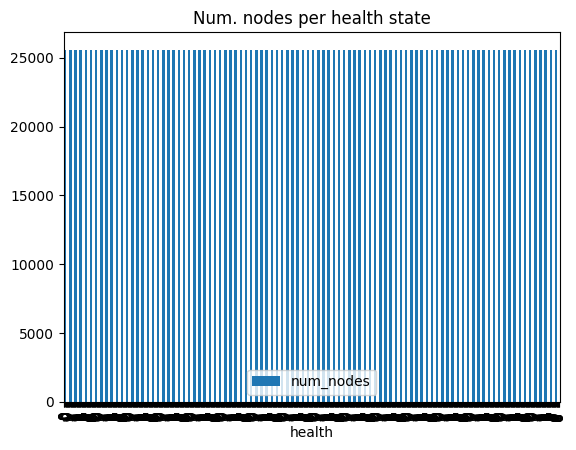

In [16]:
nn_df = pd.DataFrame(nums)
nn_df.plot(
    x="health", y="num_nodes", kind="bar",
    title=f"Num. nodes per health state"
)

In [17]:
# Save recap to file
# nn_df.to_csv("node_numbers_Data2_overview.csv", index=False)

# Visualize bridge structure

In [18]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import os
os.listdir("/content/drive/MyDrive")[:50]


['Colab Notebooks', 'programB (1)', 'programB']

In [20]:
import os

target = "nodeExport.txt"
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if target in files:
        print("找到了：", os.path.join(root, target))
        break


找到了： /content/drive/MyDrive/programB (1)/CIE_ProjectB_Group13/Data2/nodeExport.txt


In [21]:
# Read tab separated node export file
node_xyz = pd.read_csv(
    "/content/drive/MyDrive/programB (1)/CIE_ProjectB_Group13/Data2/nodeExport.txt",
    sep="\t",
    engine="python"
)


In [22]:
def select_df_subset(combination):
    """Selects a subset of the main data-frame according to the given combination.

    Args:
        combination (tuple): A tuple of (train_config, load, season, health, variable).
    """
    train_config, load, season, health, variable = combination
    var_name = VARIABLE_NAMES[variable]
    df_subset = df[
        (df["train_config"] == train_config) &
        (df["load"] == load) &
        (df["season"] == season) &
        (df["health"] == health)
    ][["Node Number", "time", var_name]]
    return df_subset

In [23]:
from ipywidgets import interact, FloatSlider

# Colors for missing nodes
missing_color = 'r'
missing_nn = {}
colors = [
    missing_color if nn in missing_nn.values() else 'b'
    for nn in node_xyz["Node Number"]
]

cmap = plt.get_cmap('viridis')

# Colors for bridge loads
combination = (0, 0, 0, 3, 0)  # Example combination

def plot_bridge_loads_3d_slider(combination):
    """
    Plots bridge loads in 3D with a time slider.
    Args:
        combination (tuple): A tuple of (train_config, load, season, health, variable).
    """
    df_subset = select_df_subset(combination)
    time_points = np.sort(df_subset["time"].unique())
    variable_to_plot = VARIABLE_NAMES[combination[-1]]

    def plot_at_time(time_point_index):
        time_point = time_points[int(time_point_index)]
        timestamp_subset = df_subset[df_subset["time"] == time_point]
        node_loads = [
            timestamp_subset[timestamp_subset["Node Number"] == nn][variable_to_plot].values
            for nn in node_xyz["Node Number"]
        ]
        node_loads_flat = [nl[0] if len(nl) > 0 else np.nan for nl in node_loads]

        fig = plt.figure(figsize=(10,10))
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(
            node_xyz["X Location (m)"],
            node_xyz["Y Location (m)"],
            node_xyz["Z Location (m)"],
            c=node_loads_flat, marker='o', s=2,
            cmap="viridis"
        )
        fig.colorbar(scatter, shrink=0.5)
        ax.set_title(f"Bridge Loads at time {time_point}\nFor combination: {combination_to_string(combination)}")
        fig.savefig(f"../visualization/bridge_loads_3d_{time_point}.png")
        # fig.show()

    interact(
        plot_at_time,
        time_point_index=FloatSlider(
            min=0,
            max=len(time_points)-1,
            step=1,
            value=0,
            description='Time Index'
        )
    )

plot_bridge_loads_3d_slider(combination)

interactive(children=(FloatSlider(value=0.0, description='Time Index', max=9.0, step=1.0), Output()), _dom_cla…

Create GIF from visualizations

In [24]:
import numpy as np
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from pathlib import Path

def create_gif_bridge_loads(
    combination,
    viz_dir="/content/drive/MyDrive/programB (1)/CIE_ProjectB_Group13/Data2/CIE_ProjectB_Group13/visualization",
    gif_name="bridge_loads_animation.gif",
    duration=0.5,   # 秒/帧
    dpi=150
):
    viz_dir = Path(viz_dir)
    viz_dir.mkdir(parents=True, exist_ok=True)

    df_subset = select_df_subset(combination)
    time_points = np.sort(df_subset["time"].unique())
    if len(time_points) == 0:
        raise ValueError("df_subset 为空：这个 combination 在 df 里没有数据")

    var = VARIABLE_NAMES[combination[-1]]

    # （可选但推荐）固定色标范围，让不同时间的颜色可比
    vmin = df_subset[var].min(skipna=True)
    vmax = df_subset[var].max(skipna=True)

    frames = []

    for t in time_points:
        timestamp_subset = df_subset[df_subset["time"] == t]

        # 按 node_xyz 顺序取值，缺失填 NaN
        node_vals = []
        for nn in node_xyz["Node Number"]:
            arr = timestamp_subset.loc[timestamp_subset["Node Number"] == nn, var].values
            node_vals.append(arr[0] if len(arr) > 0 else np.nan)

        # 固定画布像素尺寸（关键：保证每帧shape一致）
        fig = plt.figure(figsize=(10, 10), dpi=dpi)
        canvas = FigureCanvas(fig)
        ax = fig.add_subplot(111, projection="3d")

        sc = ax.scatter(
            node_xyz["X Location (m)"],
            node_xyz["Y Location (m)"],
            node_xyz["Z Location (m)"],
            c=node_vals, s=2, cmap="viridis",
            vmin=vmin, vmax=vmax
        )
        fig.colorbar(sc, shrink=0.5)
        ax.set_title(f"Bridge Loads at time {t}\n{combination_to_string(combination)}")

        canvas.draw()
        frame = np.asarray(canvas.buffer_rgba())[:, :, :3]  # RGB
        frames.append(frame)

        plt.close(fig)

    gif_path = viz_dir / gif_name
    imageio.mimsave(gif_path, frames, duration=duration)
    print("GIF saved to:", gif_path)
    return gif_path

# 例子：用你之前的 combination
combination = (0, 0, 0, 3, 0)
gif_path = create_gif_bridge_loads(combination, duration=0.5)


GIF saved to: /content/drive/MyDrive/programB (1)/CIE_ProjectB_Group13/Data2/CIE_ProjectB_Group13/visualization/bridge_loads_animation.gif


# Remove NaN

In [25]:
df.dropna(inplace=True)
df

,Node Number,season,load,health,train_config,TotalDeformation,time,DirectionalDeformation_X_axis,DirectionalDeformation_Y_axis,DirectionalDeformation_Z_axis,EquivalentStress,ShearStress_XY,ShearStress_XZ,ShearStress_YZ
0,1,0,0,0,0,0.000010,0.1,0.000003,0.000009,2.279800e-06,8727600.0,-392110.0,216100.0,517780.0
1,1,0,0,0,0,0.000011,0.5,0.000004,0.000009,4.379000e-06,14175000.0,-973950.0,420700.0,1028900.0
2,1,0,0,0,0,0.000010,0.9,0.000003,0.000009,2.283200e-06,8729500.0,-390000.0,216280.0,518170.0
3,1,0,0,0,0,0.000009,1.1,0.000004,0.000008,6.102300e-07,6162300.0,-2256900.0,-48168.0,13718.0
4,1,0,0,0,0,0.000010,1.5,0.000005,0.000008,1.077800e-06,10044000.0,-4697700.0,-115360.0,-3011.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1778515,24366,0,0,6,0,0.000024,1.9,0.000009,0.000017,1.479800e-05,2518700.0,-816050.0,-74496.0,19095.0
1778516,24366,0,0,6,0,0.000171,2.1,-0.000144,-0.000029,-8.792200e-05,9161500.0,-2776900.0,610920.0,323910.0
1778517,24366,0,0,6,0,0.000344,2.5,-0.000287,-0.000065,-1.785800e-04,17125000.0,-5029300.0,1359600.0,574700.0
1778518,24366,0,0,6,0,0.000171,2.9,-0.000143,-0.000029,-8.793200e-05,9159200.0,-2775900.0,611000.0,323630.0


# Data Inspection

In [26]:
df.dtypes

,0
Node Number,int64
season,uint8
load,uint8
health,uint8
train_config,uint8
TotalDeformation,float64
time,float64
DirectionalDeformation_X_axis,float64
DirectionalDeformation_Y_axis,float64
DirectionalDeformation_Z_axis,float64


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

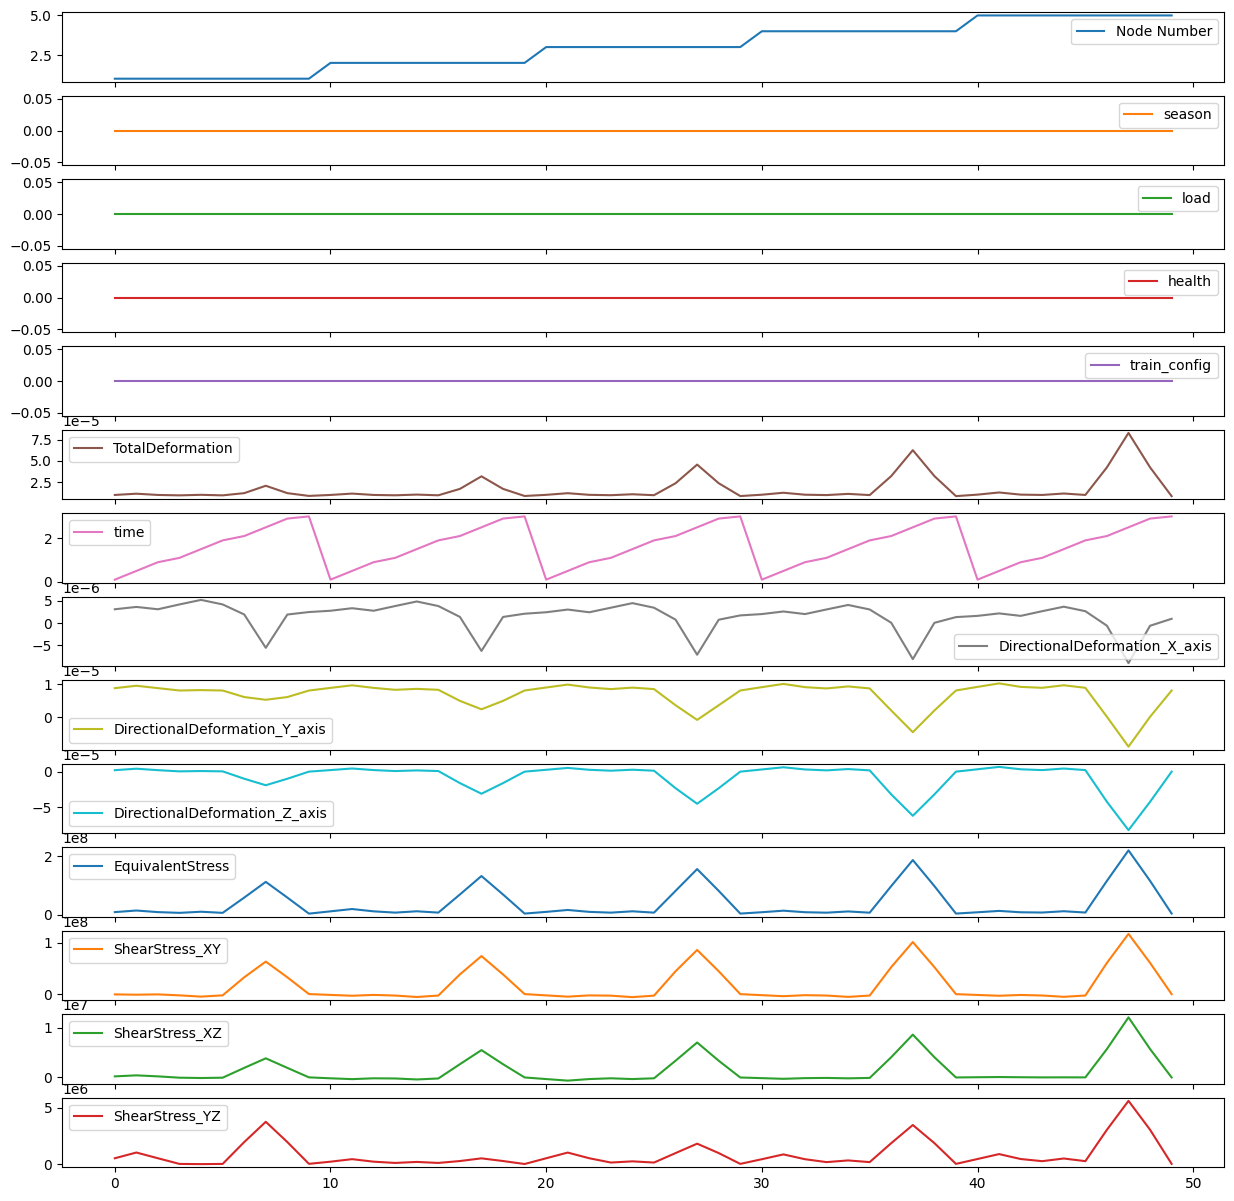

In [27]:
m = 5
df.iloc[:m*10].plot(subplots=True,figsize=(15,15))

In [28]:
df_sorted = df.sort_values(by=["Node Number","health","time"], ascending=[True, True, True])
# Attention - make sure the indices are reset after sorting
df_sorted.reset_index(drop=True, inplace=True)
df_sorted

,Node Number,season,load,health,train_config,TotalDeformation,time,DirectionalDeformation_X_axis,DirectionalDeformation_Y_axis,DirectionalDeformation_Z_axis,EquivalentStress,ShearStress_XY,ShearStress_XZ,ShearStress_YZ
0,1,0,0,0,0,0.000010,0.1,0.000003,0.000009,2.279800e-06,8727600.0,-392110.0,216100.0,517780.0
1,1,0,0,0,0,0.000011,0.5,0.000004,0.000009,4.379000e-06,14175000.0,-973950.0,420700.0,1028900.0
2,1,0,0,0,0,0.000010,0.9,0.000003,0.000009,2.283200e-06,8729500.0,-390000.0,216280.0,518170.0
3,1,0,0,0,0,0.000009,1.1,0.000004,0.000008,6.102300e-07,6162300.0,-2256900.0,-48168.0,13718.0
4,1,0,0,0,0,0.000010,1.5,0.000005,0.000008,1.077800e-06,10044000.0,-4697700.0,-115360.0,-3011.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705615,24366,0,0,6,0,0.000024,1.9,0.000009,0.000017,1.479800e-05,2518700.0,-816050.0,-74496.0,19095.0
1705616,24366,0,0,6,0,0.000171,2.1,-0.000144,-0.000029,-8.792200e-05,9161500.0,-2776900.0,610920.0,323910.0
1705617,24366,0,0,6,0,0.000344,2.5,-0.000287,-0.000065,-1.785800e-04,17125000.0,-5029300.0,1359600.0,574700.0
1705618,24366,0,0,6,0,0.000171,2.9,-0.000143,-0.000029,-8.793200e-05,9159200.0,-2775900.0,611000.0,323630.0


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

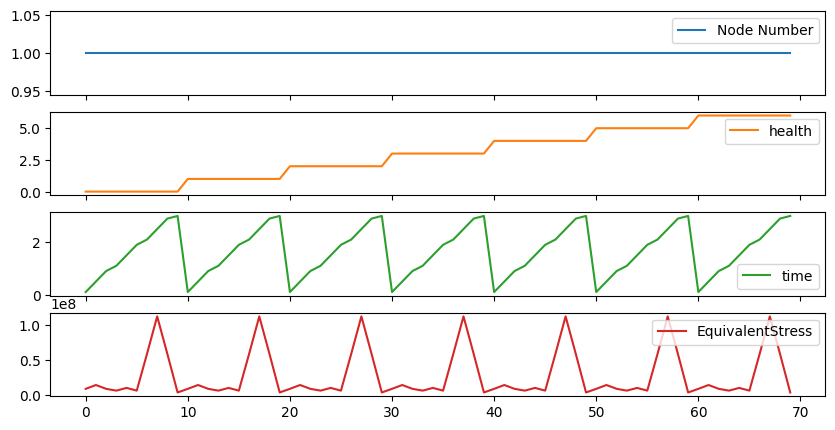

In [29]:
df_sorted[["Node Number","health","time","EquivalentStress"]].iloc[:70].plot(subplots=True,figsize=(10,5))

Compare perfect and imperfect

In [30]:
# Filter for health 0 and 1
df_comp = df_sorted[df_sorted["health"].isin([0, 1])]

df_pivot = df_comp.pivot_table(
    index=["Node Number","time","load","train_config","season"],
    columns="health",
    values=VARIABLE_NAMES
)
for variable in VARIABLE_NAMES:
    df_pivot[(variable, 'health_diff')] = df_pivot[(variable, 1)] - df_pivot[(variable, 0)]

df_diff = df_pivot[[ (var, 'health_diff') for var in VARIABLE_NAMES ]]
df_diff.columns = [var for var, _ in df_diff.columns]
df_diff.reset_index(inplace=True)
comp_diff_node_numbers = []
for var in VARIABLE_NAMES:
    for node_number in NODE_NUMBERS:
        if abs(df_diff[var][node_number]) > 0:
            comp_diff_node_numbers.append(node_number)
comp_diff_node_numbers = np.unique(comp_diff_node_numbers)
comp_diff_node_numbers

array([   55,    80,   167,   195,   227,   271,   287,   337,   417,
         489,   495,   497,   575,   617,   627,   647,   715,   735,
         737,   777,   781,   805,   829,   881,   891,   957,  1001,
        1015,  1037,  1067,  1121,  1179,  1187,  1257,  1267,  1297,
        1301,  1369,  1461,  1469,  1479,  1489,  1531,  1551,  1597,
        1667,  1776,  1911,  1961,  2047,  2117,  2229,  2247,  2397,
        2401,  2485,  2521,  2679,  2685,  2957,  3205,  3565,  3585,
        3587,  3647,  3687,  3765,  3777,  3857,  4057,  4067,  4107,
        4437,  4445,  4579,  4635,  4695,  4775,  4815,  4917,  4921,
        4977,  5007,  5047,  5069,  5127,  5665,  5707,  5711,  5767,
        5965,  6007,  6307,  6397,  6475,  6477,  6487,  6507,  6517,
        6627,  6657,  6707,  6717,  6727,  6747,  6865,  6897,  6907,
        6967,  7047,  7077,  7087,  7107,  7147,  7397,  7457,  7469,
        7479,  7507,  7511,  7547,  7657,  7667,  7677,  7709,  7714,
        7767,  7775,

Isolate nodes with changing variables

In [31]:
df_time_mean = df_sorted.groupby(by=["Node Number","health"]).mean().reset_index()
df_time_std = df_sorted.groupby(by=["Node Number","health"]).std().reset_index()

In [32]:

varying_nodes = []
for node_number in NODE_NUMBERS:
    not_same = False
    for var in VARIABLE_NAMES:
        unique_means = df_time_mean[df_time_mean["Node Number"]==node_number][var].unique()
        unique_stds = df_time_std[df_time_std["Node Number"]==node_number][var].unique()
        if len(unique_means) > 1 or len(unique_stds) > 1:
            not_same = True
    if not_same:
        varying_nodes.append(int(node_number))
len(varying_nodes), len(NODE_NUMBERS)

(7663, 25581)

In [33]:
# Only keep nodes with varying variables
df_varying = df_sorted[df_sorted["Node Number"].isin(varying_nodes)]
df_varying

,Node Number,season,load,health,train_config,TotalDeformation,time,DirectionalDeformation_X_axis,DirectionalDeformation_Y_axis,DirectionalDeformation_Z_axis,EquivalentStress,ShearStress_XY,ShearStress_XZ,ShearStress_YZ
210,4,0,0,0,0,0.000010,0.1,0.000002,0.000009,0.000003,8357700.0,-1910000.0,-138380.0,432920.00
211,4,0,0,0,0,0.000012,0.5,0.000003,0.000010,0.000006,13614000.0,-3889800.0,-276040.0,861930.00
212,4,0,0,0,0,0.000010,0.9,0.000002,0.000009,0.000003,8358100.0,-1910300.0,-138620.0,433160.00
213,4,0,0,0,0,0.000009,1.1,0.000003,0.000009,0.000002,6782800.0,-2624800.0,-95534.0,174670.00
214,4,0,0,0,0,0.000011,1.5,0.000004,0.000009,0.000004,11045000.0,-5234100.0,-180120.0,325700.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705405,24363,0,0,6,0,0.000026,1.9,0.000009,0.000019,0.000016,1678300.0,-951730.0,-109900.0,49208.00
1705406,24363,0,0,6,0,0.000180,2.1,-0.000144,-0.000031,-0.000103,8150200.0,-572360.0,704580.0,-257220.00
1705407,24363,0,0,6,0,0.000363,2.5,-0.000288,-0.000069,-0.000209,16049000.0,-705410.0,1632500.0,-476950.00
1705408,24363,0,0,6,0,0.000180,2.9,-0.000144,-0.000031,-0.000103,8149800.0,-571070.0,704440.0,-257420.00


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

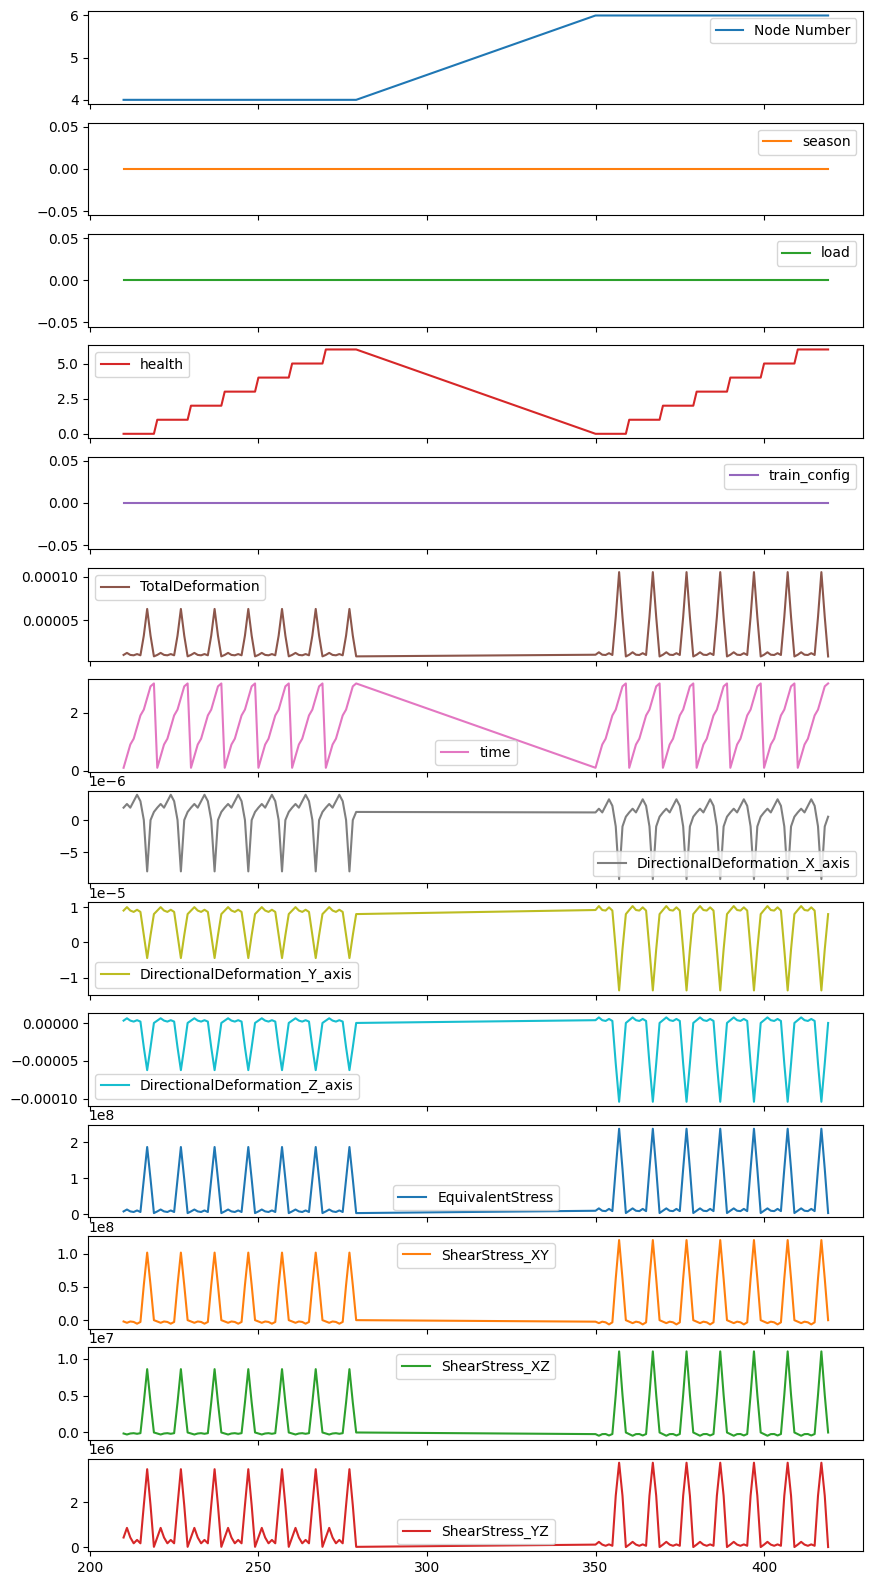

In [34]:
df_varying.iloc[:140].plot(subplots=True,figsize=(10,20))

# Figure out bridge structure

NOTE: This is now obsolete because we have the node locations.

In [35]:
len(NODE_NUMBERS)

25581

In [36]:
from ipywidgets import interact, IntSlider

def integer_factors(n):
    """Returns the list of integer factors of n."""
    factors = []
    for i in range(1, n + 1):
        if n % i == 0:
            factors.append(i)
    return factors
def plot_integer_widths(node_numbers_of_interest: list[int]):
    """Plots the bridge structure as images for all possible widths."""
    img_widths = integer_factors(len(NODE_NUMBERS))
    for w in img_widths:
        img = np.zeros((w,len(NODE_NUMBERS)//w))
        flat_img = img.flatten()
        for i,node_number in enumerate(NODE_NUMBERS):
            if node_number in node_numbers_of_interest:
                flat_img[i] = 1
        img = flat_img.reshape(img.shape)
        plt.figure(figsize=(5,5))
        plt.imshow(img, cmap='gray', interpolation='nearest')
        plt.title(f'Node Variation Map (Width: {w})')
        plt.xlabel('Node Index')
        plt.ylabel('Node Index')
        plt.show()
def plot_load_by_widths_interactive(df, timestep):
    img_widths = integer_factors(len(NODE_NUMBERS))
    times = df["time"].unique()
    if timestep not in times:
        raise ValueError(f"Timestep {timestep} not found in data. Available times: {times}")
    df_time = df[df["time"] == timestep]
    def plot_at_width(width_idx):
        w = img_widths[width_idx]
        img = np.zeros((w, len(NODE_NUMBERS)//w))
        flat_img = img.flatten()
        for i, node_number in enumerate(NODE_NUMBERS):
            load_value = df_time[df_time["Node Number"] == node_number]["TotalDeformation"].values
            assert len(load_value) <= 1, f"Multiple load values found for node {node_number} at time {timestep}"
            if len(load_value) == 1:
                flat_img[i] = load_value[0]
        img = flat_img.reshape(img.shape)
        plt.figure(figsize=(5,5))
        plt.imshow(img, cmap='viridis', interpolation='nearest')
        plt.title(f'Bridge Load Map at time {timestep} (Width: {w}), (Height: {len(NODE_NUMBERS)//w})')
        plt.xlabel('Node Index')
        plt.ylabel('Node Index')
        plt.show()
    interact(plot_at_width, width_idx=IntSlider(min=0, max=len(img_widths)-1, step=1, value=0, description='Width Index'))

def plot_load_by_time_interactive(df, width):
    times = np.sort(df["time"].unique())
    def plot_at_time(time_idx):
        time = times[time_idx]
        df_time = df[df["time"] == time]
        img = np.zeros((width, len(NODE_NUMBERS)//width))
        flat_img = img.flatten()
        for i, node_number in enumerate(NODE_NUMBERS):
            load_value = df_time[df_time["Node Number"] == node_number]["TotalDeformation"].values
            assert len(load_value) <= 1, f"Multiple load values found for node {node_number} at time {time}"
            if len(load_value) == 1:
                flat_img[i] = load_value[0]
        img = flat_img.reshape(img.shape)
        plt.figure(figsize=(5,5))
        plt.imshow(img, cmap='viridis', interpolation='nearest')
        plt.title(f'Bridge Load Map at time {time} (Width: {width})')
        plt.xlabel('Node Index')
        plt.ylabel('Node Index')
        plt.show()
    interact(plot_at_time, time_idx=IntSlider(min=0, max=len(times)-1, step=1, value=0, description='Time Index'))


plot_load_by_widths_interactive(df_sorted[df_sorted["health"]==0], timestep=0.1)
plot_load_by_time_interactive(df_sorted[df_sorted["health"]==0], width=34)

interactive(children=(IntSlider(value=0, description='Width Index', max=3), Output()), _dom_classes=('widget-i…

interactive(children=(IntSlider(value=0, description='Time Index', max=9), Output()), _dom_classes=('widget-in…

In [37]:
2210/(42*3)

17.53968253968254

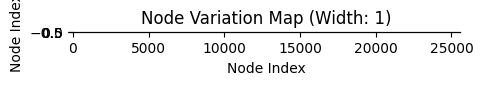

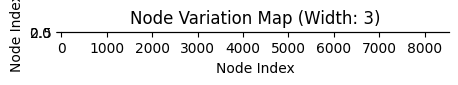

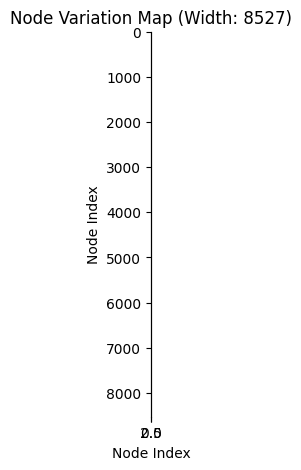

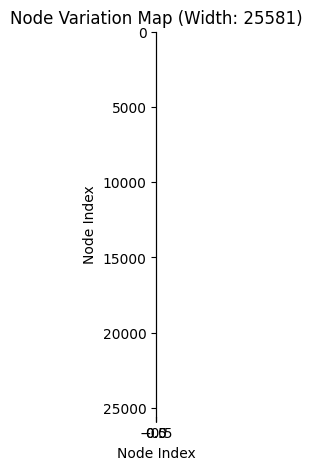

In [38]:
plot_integer_widths(comp_diff_node_numbers)

# Training

In [39]:
df_train = df_varying.copy()

In [40]:
X_raw, y_raw = df_train.drop(columns=["health"]), df_train["health"]
X_train_raw, X_test_raw, y_train, y_test = sklearn.model_selection.train_test_split(
    X_raw, y_raw, test_size = 0.1, random_state = 0, shuffle=True,
)

In [41]:
def standardize(X_train_raw, X_test_raw):
    scaler = sklearn.preprocessing.StandardScaler()

    scaler.fit(X_train_raw)
    X_train = scaler.transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    return X_train, X_test

X_train, X_test = standardize(X_train_raw, X_test_raw)

# Compare imperfect and imperfect

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def _assert_cols(df, cols, name="df"):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name} 缺少列: {missing}")

base_cols = ["Node Number","time","train_config","load","season","health"]
_assert_cols(df_sorted, base_cols, "df_sorted")
_assert_cols(df_sorted, VARIABLE_NAMES, "df_sorted")

df_sorted["Node Number"] = df_sorted["Node Number"].astype(np.int64)
df_sorted["health"] = df_sorted["health"].astype(np.int8)
df_sorted["season"] = df_sorted["season"].astype(np.int8)
df_sorted["load"] = df_sorted["load"].astype(np.int8)
df_sorted["train_config"] = df_sorted["train_config"].astype(np.int8)


In [43]:
def compute_imperfect_node_scores(
    df: pd.DataFrame,
    variables: list,
    base_health: int = 0,
    imperfect_healths=(1,2,3,4,5,6),
    reducer: str = "rms",
    combine_vars: str = "sum",
    eps: float = 1e-12
):
    """
    For scenario(train_config,load,season):
      Perfect(health=0) vs each Imperfect(health=1..6)
      Compute the difference and normalise it, then aggregate by time to obtain the score for each node.
Return:
      final_scores: each Node Number a final score
    """
    scenario_cols = ["train_config","load","season"]
    key_cols = scenario_cols + ["Node Number","time"]

    results = []

    for scen_key, df_scen in df.groupby(scenario_cols, sort=False):
        df0 = df_scen[df_scen["health"] == base_health]
        if df0.empty:
            continue

        base = (
            df0[key_cols + list(variables)]
            .set_index(key_cols)
            .sort_index()
        )

        std_per_var = base[variables].std(axis=0)
        std_per_var = std_per_var.replace(0, np.nan)

        per_h_scores = {}

        for h in imperfect_healths:
            dfh = df_scen[df_scen["health"] == h]
            if dfh.empty:
                continue

            imp = (
                dfh[key_cols + list(variables)]
                .set_index(key_cols)
                .sort_index()
            )

            common_index = base.index.intersection(imp.index)
            if len(common_index) == 0:
                continue

            d = imp.loc[common_index, variables] - base.loc[common_index, variables]
            d_norm = d / (std_per_var + eps)

            if reducer == "rms":
                node_var = d_norm.groupby(level=3).apply(lambda x: np.sqrt((x**2).mean(axis=0)))
            elif reducer == "max":
                node_var = d_norm.abs().groupby(level=3).max()
            else:
                raise ValueError

            if combine_vars == "sum":
                node_score = node_var.sum(axis=1)
            elif combine_vars == "max":
                node_score = node_var.max(axis=1)
            else:
                raise ValueError

            per_h_scores[h] = node_score

        if not per_h_scores:
            continue

        df_scores = pd.DataFrame(per_h_scores)         # columns = healths
        df_scores["score"] = df_scores.max(axis=1)     # health for max
        df_scores = df_scores.reset_index().rename(columns={"index": "Node Number"})

        df_scores["train_config"], df_scores["load"], df_scores["season"] = scen_key
        results.append(df_scores)

    if not results:
        raise RuntimeError

    scores_by_scenario = pd.concat(results, ignore_index=True)

    final_scores = (
        scores_by_scenario.groupby("Node Number", as_index=False)["score"]
        .mean()
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )

    return final_scores, scores_by_scenario



In [44]:

final_scores, scores_by_scenario = compute_imperfect_node_scores(
    df_sorted,
    variables=VARIABLE_NAMES,
    reducer="rms",
    combine_vars="sum"
)

final_scores.head(20)

,Node Number,score
0,14029,0.184980
1,23162,0.091985
2,12012,0.000321
3,13218,0.000109
4,11779,0.000109
5,11171,0.000109
6,11419,0.000109
7,15600,0.000109
8,6119,0.000090
9,5382,0.000079


In [45]:
# Top 1%
k = max(1, int(0.01 * len(final_scores)))
suspects = final_scores.head(k)["Node Number"].tolist()
k, suspects[:10]


(243, [14029, 23162, 12012, 13218, 11779, 11171, 11419, 15600, 6119, 5382])

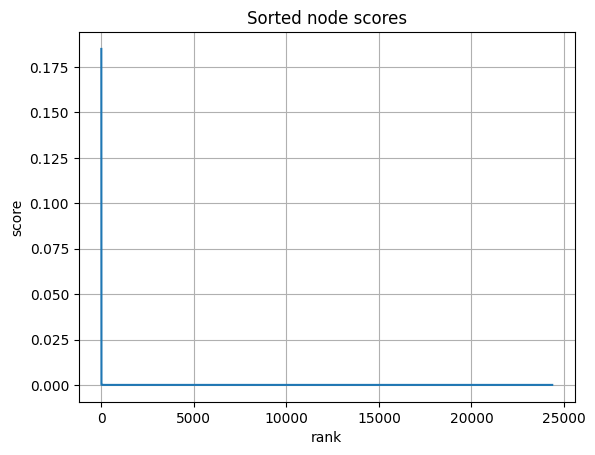

In [46]:
# Look at the "inflection point"
plt.figure()
plt.plot(final_scores["score"].values)
plt.title("Sorted node scores")
plt.xlabel("rank")
plt.ylabel("score")
plt.grid(True)
plt.show()


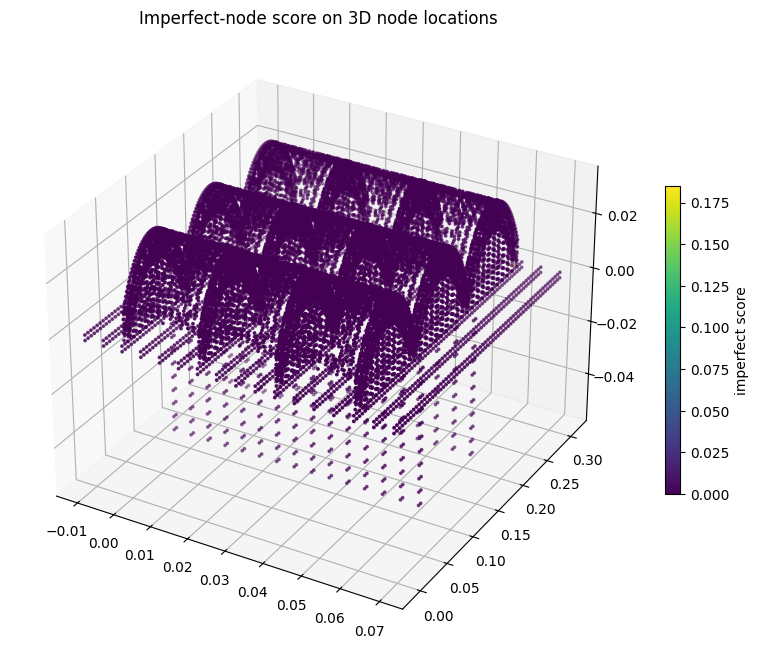

In [47]:
# check node_xyz
_assert_cols(node_xyz, ["Node Number","X Location (m)","Y Location (m)","Z Location (m)"], "node_xyz")

viz = node_xyz.merge(final_scores, on="Node Number", how="left")
viz["score"] = viz["score"].fillna(0.0)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(
    viz["X Location (m)"],
    viz["Y Location (m)"],
    viz["Z Location (m)"],
    c=viz["score"],
    s=3,
    cmap="viridis"
)
fig.colorbar(sc, shrink=0.5, label="imperfect score")
ax.set_title("Imperfect-node score on 3D node locations")
plt.show()


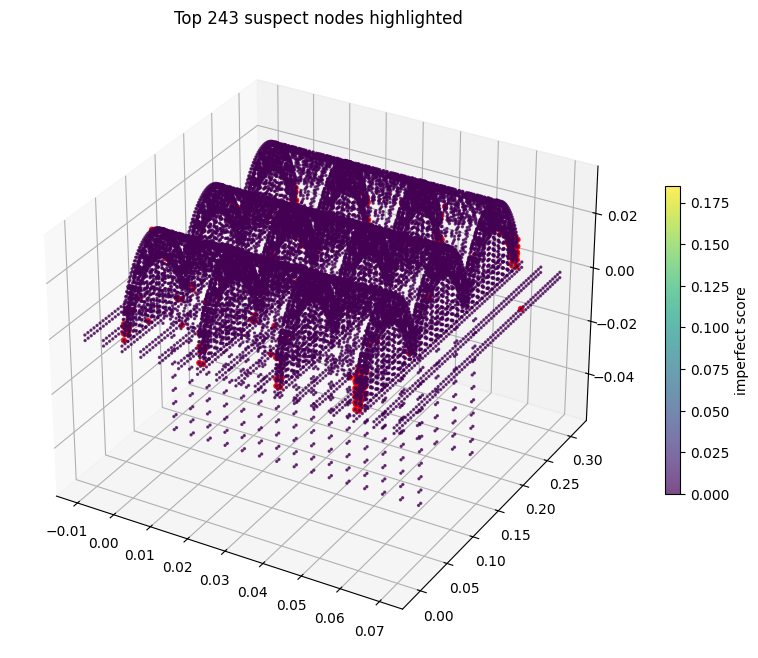

In [48]:
viz["is_suspect"] = viz["Node Number"].isin(suspects)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(
    viz["X Location (m)"], viz["Y Location (m)"], viz["Z Location (m)"],
    c=viz["score"], s=2, cmap="viridis", alpha=0.7
)
fig.colorbar(sc, shrink=0.5, label="imperfect score")

sdf = viz[viz["is_suspect"]]
ax.scatter(
    sdf["X Location (m)"], sdf["Y Location (m)"], sdf["Z Location (m)"],
    c="r", s=12, marker="o", alpha=0.9
)
ax.set_title(f"Top {k} suspect nodes highlighted")
plt.show()


Decision Tree

In [49]:
# model = sklearn.tree.DecisionTreeClassifier()
# model.fit(X_train, y_train)

In [50]:
# model.score(X_test, y_test), model.score(X_train, y_train)

Neural Network

In [51]:
# model = sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(1000,1000,1000),verbose=1)
# model.fit(X_train, y_train)

In [52]:
# model.score(X_test, y_test), model.score(X_train, y_train)

In [97]:
import os, sys, random, re, shutil
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

def set_seed(seed=8):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(8)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

REPO_ROOT = "/content/CIE_ProjectB_Group13"
os.chdir(REPO_ROOT)
sys.path.append(REPO_ROOT)

from _import import *
print("Imported project modules.")


device: cpu
Imported project modules.


In [98]:
import os, shutil

DRIVE_DATA2 = "/content/drive/.shortcut-targets-by-id/1s4mXuvtXeACi0SlotRW51MJ2xu6p5JfN/programB/Data2"

# 清理旧 data
if os.path.islink("data") or os.path.isfile("data"):
    os.remove("data")
elif os.path.isdir("data"):
    shutil.rmtree("data")

os.symlink(DRIVE_DATA2, "data")
print("Symlink created: data ->", os.path.realpath("data"))
print("data dir list (first 20):", os.listdir("data")[:20])


Symlink created: data -> /content/drive/.shortcut-targets-by-id/1s4mXuvtXeACi0SlotRW51MJ2xu6p5JfN/programB/Data2
data dir list (first 20): ['CIE_ProjectB_Group13', 'One_train_middle_track', 'Two_trains_extreme_track_same_direction', 'Two_trains_extreme_track_same_direction_smalltrain_winter_case(ip_2_arc_all_tracks_222)', 'Two_trains_extreme_track_different_direction', 'One_train_1st_track', 'nodeExport.txt', 'stress_diff_frames', 'df_pivot_complete.xlsx', 'TwoTrainsSameDir__BiggerTrain__Summer__ip_first_track_3arc_78910__stress_nonzero_nodes.csv', 'scenario_zero_stress_summary.csv', 'scenario_zero_stress_summary_with_examples.csv', 'TwoTrainsSameDir__BiggerTrain__Summer__health3_vs_health0__unchanged_stress_nodes.csv', 'TwoTrainsSameDir__BiggerTrain__Summer__health3_vs_health0__unchanged_stress_nodes_table.csv', 'OneTrain1stTrack__BiggerTrain__Summer__health1_vs_health0__stress_compare_table.csv', 'OneTrain1stTrack__BiggerTrain__Summer__health1_vs_health0__changed_nodes.csv', 'OneTrai

In [99]:
import pickle

with open("delta_nodes_superset_0.0001_top_pct.pkl", "rb") as f:
    node_subset = pickle.load(f)

node_subset = [int(x) for x in node_subset]
print("node_subset n =", len(node_subset), "first10 =", node_subset[:10])


node_subset n = 2552 first10 = [16384, 16387, 8197, 6, 16391, 8201, 14, 15, 16398, 16401]


In [100]:
from pathlib import Path
import re

DATA_ROOT = Path("data")

def _norm(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(s).lower())

TEXT_EXTS = {".csv", ".txt", ".tsv", ".dat"}
ALL_FILES = [p for p in DATA_ROOT.rglob("*") if p.is_file() and p.suffix.lower() in TEXT_EXTS]
ALL_FILES_NORM = [_norm(str(p)) for p in ALL_FILES]

print("Indexed text-like files:", len(ALL_FILES))
print("Example:", ALL_FILES[:5])


Indexed text-like files: 924
Example: [PosixPath('data/nodeExport.txt'), PosixPath('data/TwoTrainsSameDir__BiggerTrain__Summer__ip_first_track_3arc_78910__stress_nonzero_nodes.csv'), PosixPath('data/scenario_zero_stress_summary.csv'), PosixPath('data/scenario_zero_stress_summary_with_examples.csv'), PosixPath('data/TwoTrainsSameDir__BiggerTrain__Summer__health3_vs_health0__unchanged_stress_nodes.csv')]


In [101]:
import numpy as np
import pandas as pd

def fuzzy_find_data_file(train_config: int, load: int, season: int, region: int, variable: int) -> Path:
    train_tokens  = {_norm(TRAIN_CONFIGS[train_config]), _norm(train_config)}
    load_tokens   = {_norm(LOADS[load]), _norm(load)}
    season_tokens = {_norm(SEASONS[season]), _norm(season)}
    region_tokens = {_norm(REGIONS[region]), _norm(region)}
    var_tokens    = {_norm(VARIABLES[variable]), _norm(variable)}

    candidates = []
    for p, pn in zip(ALL_FILES, ALL_FILES_NORM):
        if (any(t in pn for t in train_tokens) and
            any(t in pn for t in load_tokens) and
            any(t in pn for t in season_tokens) and
            any(t in pn for t in region_tokens) and
            any(t in pn for t in var_tokens)):
            candidates.append(p)

    if not candidates:
        raise FileNotFoundError(
            "Could not fuzzy-match TEXT file for: "
            f"{TRAIN_CONFIGS[train_config]} / {LOADS[load]} / {SEASONS[season]} / "
            f"{REGIONS[region]} / {VARIABLES[variable]}"
        )

    # Prefer shorter path and larger file (avoid tiny summaries when possible)
    candidates.sort(key=lambda p: (len(str(p)), -p.stat().st_size))
    return candidates[0]


def normalize_time_series(s: pd.Series) -> pd.Series:
    def _to_float(x):
        if pd.isna(x):
            return np.nan
        if isinstance(x, (int, float, np.integer, np.floating)):
            return float(x)
        m = re.findall(r"[-+]?\d*\.?\d+", str(x))
        return float(m[0]) if m else np.nan
    return s.map(_to_float).astype(float)


def read_file_to_long(path: Path, var_name: str) -> pd.DataFrame:
    # Try common encodings
    last_err = None
    for enc in ["utf-8", "latin1", "cp1252"]:
        try:
            df = pd.read_csv(path, sep=None, engine="python", encoding=enc)
            last_err = None
            break
        except UnicodeDecodeError as e:
            last_err = e
            continue
    if last_err is not None:
        raise last_err

    df.columns = [str(c).strip() for c in df.columns]

    # Case 1: already long
    if "time" in df.columns and "Node Number" in df.columns:
        if var_name in df.columns:
            out = df[["Node Number", "time", var_name]].copy()
        else:
            val_cols = [c for c in df.columns if c not in ["Node Number", "time"]]
            if not val_cols:
                raise ValueError(f"No value column found in {path}")
            out = df[["Node Number", "time", val_cols[0]]].copy()
            out.rename(columns={val_cols[0]: var_name}, inplace=True)

        out["Node Number"] = out["Node Number"].astype(int)
        out["time"] = normalize_time_series(out["time"])
        out = out.dropna(subset=["time"])
        return out

    # Case 2: wide -> melt
    if "Node Number" not in df.columns:
        df.rename(columns={df.columns[0]: "Node Number"}, inplace=True)

    value_cols = [c for c in df.columns if c != "Node Number"]
    out = df.melt(id_vars=["Node Number"], value_vars=value_cols, var_name="time", value_name=var_name)

    out["Node Number"] = out["Node Number"].astype(int)
    out["time"] = normalize_time_series(out["time"])
    out = out.dropna(subset=["time"])
    return out

print("Matcher + reader ready.")


Matcher + reader ready.


In [103]:
# ---------- Replace fuzzy matcher with a stricter one ----------
BLACKLIST_PATTERNS = [
    "changed_nodes", "unchanged_nodes",
    "compare_table", "ratio_summary", "summary",
    "nonzero_nodes", "overview",
    "nodeexport", "valid_node_numbers", "all_node_numbers",
    "stress_diff_frames", "xlsx"
]

def is_blacklisted(path: Path) -> bool:
    pn = _norm(str(path))
    return any(_norm(b) in pn for b in BLACKLIST_PATTERNS)

def fuzzy_find_data_file(train_config: int, load: int, season: int, region: int, variable: int) -> Path:
    # IMPORTANT: only use NAME tokens (no numeric tokens)
    train_token  = _norm(TRAIN_CONFIGS[train_config])
    load_token   = _norm(LOADS[load])
    season_token = _norm(SEASONS[season])
    region_token = _norm(REGIONS[region])
    var_token    = _norm(VARIABLES[variable])

    candidates = []
    for p, pn in zip(ALL_FILES, ALL_FILES_NORM):
        if is_blacklisted(p):
            continue
        # Must match all name tokens
        if (train_token in pn and
            load_token in pn and
            season_token in pn and
            region_token in pn and
            var_token in pn):
            candidates.append(p)

    if not candidates:
        # Debug hint: show tokens
        raise FileNotFoundError(
            "Strict fuzzy-match failed for:\n"
            f"  train={TRAIN_CONFIGS[train_config]} (token={train_token})\n"
            f"  load={LOADS[load]} (token={load_token})\n"
            f"  season={SEASONS[season]} (token={season_token})\n"
            f"  region={REGIONS[region]} (token={region_token})\n"
            f"  var={VARIABLES[variable]} (token={var_token})\n"
        )

    # prefer bigger file (raw data tends to be bigger)
    candidates.sort(key=lambda p: -p.stat().st_size)
    return candidates[0]

print("Updated strict fuzzy matcher ready.")


Updated strict fuzzy matcher ready.


In [104]:
import pandas as pd

# 只用小规模先验证 pipeline
scenario_keys = sorted(set((c[0], c[1], c[2]) for c in combinations))
selected_scenarios = scenario_keys[:1]   # 先1个
region_list = [0, 1]                     # 先2个（perfect/defect）
var_ids = sorted(VARIABLES.keys())[:2]   # 先2个变量
var_names = [VARIABLES[i] for i in var_ids]

print("Selected scenarios:", selected_scenarios)
print("Regions:", region_list)
print("Vars:", var_names)

dfs = []
for (train_config, load, season) in selected_scenarios:
    for region in region_list:
        base = None
        for vid in var_ids:
            p = fuzzy_find_data_file(train_config, load, season, region, vid)
            print("Matched:", p)

            d = read_file_to_long(p, VARIABLES[vid])
            d["time"] = d["time"].astype(float)

            if base is None:
                base = d
            else:
                base["time"] = base["time"].astype(float)
                base = base.merge(d, on=["Node Number","time"], how="inner")

        base["train_config"] = train_config
        base["load"] = load
        base["season"] = season
        base["region"] = region
        base["health_bin"] = 0 if region == 0 else 1
        base["scenario"] = f"{train_config}__{load}__{season}__region{region}"
        dfs.append(base)

df_long_small = pd.concat(dfs, ignore_index=True)

# 过滤到 node_subset（减少体量）
df_long_small = df_long_small[df_long_small["Node Number"].isin(node_subset)].copy()

print("df_long_small shape:", df_long_small.shape)
print("time unique (first 20):", sorted(df_long_small["time"].unique())[:20])
print("label counts:", df_long_small.groupby("scenario")["health_bin"].first().value_counts())
df_long_small.head()


Selected scenarios: [(0, 0, 0)]
Regions: [0, 1]
Vars: ['TotalDeformation', 'DirectionalDeformation_X_axis']
Matched: data/One_train_1st_track/Bigger_train/Summer/Perfect_structure/Results1/TotalDeformation.csv
Matched: data/One_train_1st_track/Bigger_train/Summer/Perfect_structure/Results1/DirectionalDeformation_X_axis.csv
Matched: data/One_train_1st_track/Bigger_train/Summer/ip_frst_Arc_defect_all_tracks_111/Results1/TotalDeformation.csv
Matched: data/One_train_1st_track/Bigger_train/Summer/ip_frst_Arc_defect_all_tracks_111/Results1/DirectionalDeformation_X_axis.csv
df_long_small shape: (51040, 10)
time unique (first 20): [np.float64(0.1), np.float64(0.5), np.float64(0.9), np.float64(1.1), np.float64(1.5), np.float64(1.9), np.float64(2.1), np.float64(2.5), np.float64(2.9), np.float64(3.0)]
label counts: health_bin
0    1
1    1
Name: count, dtype: int64


,Node Number,time,TotalDeformation,DirectionalDeformation_X_axis,train_config,load,season,region,health_bin,scenario
5,6,0.1,0.000010,1.238800e-06,0,0,0,0,0,0__0__0__region0
13,14,0.1,0.000013,-1.722900e-06,0,0,0,0,0,0__0__0__region0
14,15,0.1,0.000013,-2.074300e-06,0,0,0,0,0,0__0__0__region0
25,26,0.1,0.000015,-4.890300e-07,0,0,0,0,0,0__0__0__region0
28,29,0.1,0.000018,-1.585900e-06,0,0,0,0,0,0__0__0__region0


In [105]:
import pandas as pd

# 正式规模
scenario_keys = sorted(set((c[0], c[1], c[2]) for c in combinations))
selected_scenarios = scenario_keys[:6]        # 6个 (train_config, load, season)
region_list = [0,1,2,3,4,5,6]                 # 0=Perfect, 1..6=defects
var_ids = sorted(VARIABLES.keys())            # 8个变量
var_names = [VARIABLES[i] for i in var_ids]

print("Selected scenarios:", selected_scenarios)
print("Regions:", region_list)
print("Vars:", var_names)

# 简单缓存：同一个文件不会重复读（加速）
_file_cache = {}

def read_cached_long(path: Path, var_name: str) -> pd.DataFrame:
    key = (str(path), var_name)
    if key not in _file_cache:
        _file_cache[key] = read_file_to_long(path, var_name)
    return _file_cache[key].copy()

dfs = []
count_total = len(selected_scenarios) * len(region_list) * len(var_ids)
count_done = 0

for (train_config, load, season) in selected_scenarios:
    for region in region_list:
        base = None
        for vid in var_ids:
            p = fuzzy_find_data_file(train_config, load, season, region, vid)
            d = read_cached_long(p, VARIABLES[vid])
            d["time"] = d["time"].astype(float)

            if base is None:
                base = d
            else:
                base["time"] = base["time"].astype(float)
                base = base.merge(d, on=["Node Number","time"], how="inner")

            count_done += 1
            if count_done % 20 == 0:
                print(f"Progress: {count_done}/{count_total} files")

        base["train_config"] = train_config
        base["load"] = load
        base["season"] = season
        base["region"] = region
        base["health_bin"] = 0 if region == 0 else 1
        base["scenario"] = f"{train_config}__{load}__{season}__region{region}"
        dfs.append(base)

df_long = pd.concat(dfs, ignore_index=True)

# 只保留 delta nodes（2552个）
df_long = df_long[df_long["Node Number"].isin(node_subset)].copy()

print("df_long shape:", df_long.shape)
print("n_scenarios:", df_long["scenario"].nunique())
print("time steps:", sorted(df_long["time"].unique()))
print("label counts (per scenario):")
print(df_long.groupby("scenario")["health_bin"].first().value_counts())


Selected scenarios: [(0, 0, 0), (0, 0, 1), (0, 1, 0), (0, 1, 1), (1, 0, 0), (1, 0, 1)]
Regions: [0, 1, 2, 3, 4, 5, 6]
Vars: ['TotalDeformation', 'DirectionalDeformation_X_axis', 'DirectionalDeformation_Y_axis', 'DirectionalDeformation_Z_axis', 'EquivalentStress', 'ShearStress_XY', 'ShearStress_XZ', 'ShearStress_YZ']
Progress: 20/336 files
Progress: 40/336 files
Progress: 60/336 files
Progress: 80/336 files
Progress: 100/336 files
Progress: 120/336 files
Progress: 140/336 files
Progress: 160/336 files
Progress: 180/336 files
Progress: 200/336 files
Progress: 220/336 files
Progress: 240/336 files
Progress: 260/336 files
Progress: 280/336 files
Progress: 300/336 files
Progress: 320/336 files
df_long shape: (1071840, 16)
n_scenarios: 42
time steps: [np.float64(0.1), np.float64(0.5), np.float64(0.9), np.float64(1.1), np.float64(1.5), np.float64(1.9), np.float64(2.1), np.float64(2.5), np.float64(2.9), np.float64(3.0)]
label counts (per scenario):
health_bin
1    36
0     6
Name: count, dtype

In [106]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader

def build_scenario_tensors(df_long: pd.DataFrame, node_subset: list[int], var_names: list[str], fill_value=0.0):
    df = df_long.copy()

    nodes_order = np.array(sorted(set(node_subset)), dtype=int)
    times_order = np.array(sorted(df["time"].unique()), dtype=float)

    scen_y = df.groupby("scenario")["health_bin"].first()
    scenarios = scen_y.index.to_list()
    y = scen_y.astype(int).to_numpy()

    C, N, T = len(var_names), len(nodes_order), len(times_order)
    X = np.full((len(scenarios), C, N, T), fill_value, dtype=np.float32)

    keep_cols = ["scenario","time","Node Number","health_bin"] + list(var_names)
    df = df[keep_cols]

    for i, scen in enumerate(scenarios):
        dsc = df[df["scenario"] == scen]
        for c, v in enumerate(var_names):
            pv = dsc.pivot_table(index="Node Number", columns="time", values=v, aggfunc="first")
            pv = pv.reindex(index=nodes_order, columns=times_order)
            X[i, c, :, :] = pv.to_numpy(dtype=np.float32)

    return torch.from_numpy(X), torch.from_numpy(y).long(), scenarios

X_all, y_all, scenarios = build_scenario_tensors(df_long, node_subset, var_names)
print("X_all:", tuple(X_all.shape), "y_all:", tuple(y_all.shape), "pos_rate:", float(y_all.float().mean()))

# stratified split
idx = np.arange(len(scenarios))
train_idx, test_idx = train_test_split(idx, test_size=0.25, random_state=8, stratify=y_all.numpy())

X_train_raw, y_train = X_all[train_idx], y_all[train_idx]
X_test_raw,  y_test  = X_all[test_idx],  y_all[test_idx]

def channelwise_standardize(train_X, test_X, eps=1e-6):
    mean = train_X.mean(dim=(0,2,3), keepdim=True)
    std  = train_X.std(dim=(0,2,3), keepdim=True)
    std = torch.clamp(std, min=eps)
    return (train_X-mean)/std, (test_X-mean)/std

X_train, X_test = channelwise_standardize(X_train_raw, X_test_raw)

class ScenarioDataset(Dataset):
    def __init__(self, X, y): self.X, self.y = X, y
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(ScenarioDataset(X_train, y_train), batch_size=8, shuffle=True)
test_loader  = DataLoader(ScenarioDataset(X_test,  y_test),  batch_size=8, shuffle=False)

class SHM_CNN2D(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.head(self.features(x)).squeeze(1)

def train_binary_cnn(model, train_loader, test_loader, epochs=10, lr=1e-3):
    model.to(device)

    all_y = torch.cat([y for _, y in train_loader], dim=0)
    n_pos = (all_y == 1).sum().item()
    n_neg = (all_y == 0).sum().item()
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], device=device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optim = torch.optim.Adam(model.parameters(), lr=lr)

    for ep in range(1, epochs+1):
        model.train()
        loss_sum = 0.0
        for Xb, yb in train_loader:
            Xb = Xb.to(device)
            yb = yb.float().to(device)

            optim.zero_grad()
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            optim.step()

            loss_sum += loss.item() * Xb.size(0)

        model.eval()
        y_true, y_pred = [], []
        with torch.no_grad():
            for Xb, yb in test_loader:
                prob = torch.sigmoid(model(Xb.to(device))).cpu().numpy()
                pred = (prob >= 0.5).astype(int)
                y_true.append(yb.numpy())
                y_pred.append(pred)

        y_true = np.concatenate(y_true)
        y_pred = np.concatenate(y_pred)

        print(f"\nEpoch {ep:02d} | train_loss={loss_sum/len(train_loader.dataset):.4f}")
        print(classification_report(y_true, y_pred, digits=4))
        print("Confusion matrix:\n", confusion_matrix(y_true, y_pred, labels=[0,1]))

    return model

model = SHM_CNN2D(in_channels=len(var_names))
model = train_binary_cnn(model, train_loader, test_loader, epochs=10, lr=1e-3)


X_all: (42, 8, 2552, 10) y_all: (42,) pos_rate: 0.8571428656578064

Epoch 01 | train_loss=0.1849
              precision    recall  f1-score   support

           0     0.1429    0.5000    0.2222         2
           1     0.7500    0.3333    0.4615         9

    accuracy                         0.3636        11
   macro avg     0.4464    0.4167    0.3419        11
weighted avg     0.6396    0.3636    0.4180        11

Confusion matrix:
 [[1 1]
 [6 3]]

Epoch 02 | train_loss=0.1798
              precision    recall  f1-score   support

           0     0.1429    0.5000    0.2222         2
           1     0.7500    0.3333    0.4615         9

    accuracy                         0.3636        11
   macro avg     0.4464    0.4167    0.3419        11
weighted avg     0.6396    0.3636    0.4180        11

Confusion matrix:
 [[1 1]
 [6 3]]

Epoch 03 | train_loss=0.1804
              precision    recall  f1-score   support

           0     0.1429    0.5000    0.2222         2
           1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.




Epoch 06 | train_loss=0.1769
              precision    recall  f1-score   support

           0     0.1429    0.5000    0.2222         2
           1     0.7500    0.3333    0.4615         9

    accuracy                         0.3636        11
   macro avg     0.4464    0.4167    0.3419        11
weighted avg     0.6396    0.3636    0.4180        11

Confusion matrix:
 [[1 1]
 [6 3]]

Epoch 07 | train_loss=0.1770
              precision    recall  f1-score   support

           0     0.1429    0.5000    0.2222         2
           1     0.7500    0.3333    0.4615         9

    accuracy                         0.3636        11
   macro avg     0.4464    0.4167    0.3419        11
weighted avg     0.6396    0.3636    0.4180        11

Confusion matrix:
 [[1 1]
 [6 3]]

Epoch 08 | train_loss=0.1797
              precision    recall  f1-score   support

           0     0.1429    0.5000    0.2222         2
           1     0.7500    0.3333    0.4615         9

    accuracy            